# The data used in ths example is generated with random values

In [1]:
#Script used for generating the data set
#Errors added to the set for exercise purposes


#import random
#print(StudentID,Age,email,hrsStudy,FinalGrade)
#for i in range(50):
#    studId ="s" + str(random.randrange(10000,99999,1)) 
#    print(str(studId)+","+ str(random.randrange(19,35,1))+","+str(studId+"@oslomet.no"+","+str(random.randint(0, 12)))+","+str(random.randint(20, 100)))


In [2]:
#Import modules
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib as plt

In [3]:
#Import csv file
url = 'https://raw.githubusercontent.com/DAVE3625/Dave3625-2026/refs/heads/main/Lab2/data/stud.csv'


In [4]:
#Read the csv, notice sep=','.. For CSV files created in Norwegian excel we need to use sep=';'#
#df = pd.read_csv(url, na_values=' ') You can use this for automatically convert blank space to nan values
df = pd.read_csv(url, sep=',')

df.head()

,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0


In [5]:
df.describe()

,StudentID,FinalGrade
count,50.000000,49.000000
mean,48969.820000,71.653061
std,26870.066326,90.455917
min,10736.000000,24.000000
25%,26666.500000,39.000000
50%,44292.000000,60.000000
75%,70400.250000,78.000000
max,99823.000000,673.000000


Ok, so we only get describe data for two columns.. Why?
Pandas will try to calculate for all rows, but since calculation only can be done on numbers, columns that's not int / float will be skipped
From the printout df.head(5), it looks like StudentId, Age, hrsStudy and FinalGrade is int / float, but lets check



In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   50 non-null     int64  
 1   Age         50 non-null     str    
 2   email       50 non-null     str    
 3   hrsStudy    50 non-null     str    
 4   FinalGrade  49 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.1 KB


Age, email, hrsStudy are Dtype(O) (object).. How did this happen? Lets take a look on all 50 rows 

In [7]:
df

,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0
5,88403,29,s88403@oslomet.no,11,62.0
6,56387,32,s56387@oslomet.no,9,29.0
7,95648,23,s95648@oslomet.no,3,38.0
8,63176,20,s63176@oslomet.no,0,98.0
9,15406,31,s15406@oslomet.no,2,68.0


As you can see, row 30 and 41 have missing values. So for us to convert the columns into int type, we need to decide 
what we want to do with them.
1. Delete the row ( this could be a good solution if we have a big dataset or we need to have reliable data)
2. Fill the empty value with a dummy value
Lets say that "Age" isen't to important, and we decide to fill empty values with 0,
but we don't want to fill dummy data for hrsStudy, so we will delete rows with empty data here


In [8]:
#lets see how many empty cells we got
df.isna().sum()

StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    1
dtype: int64

This can't be correct, we have seen that we have at least 1 empty cell in both Age and hrsStudy.. Lets fix this by using np.nan

In [9]:
#Lets first replace all empty cells wit np.nan
df=df.replace(r'^\s*$', np.nan, regex=True)
#and check again
df.isna().sum()

StudentID     0
Age           1
email         0
hrsStudy      1
FinalGrade    1
dtype: int64

In [10]:
#When dealing with missing values, we need to make to figure out if we can replace data
#with dummy values. Lets say Age isn't too important in this dataset, and we can replace missing
#age values with 0

df["Age"].replace(np.nan, 0, inplace=True)
#df = df['Age'].astype(str).astype(int)

/var/folders/gk/p4lwbnk179sckbsdq4vn1mhm0000gn/T/ipykernel_70419/18981390.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].replace(np.nan, 0, inplace=True)


0      20
1      22
2      27
3      21
4     333
5      29
6      32
7      23
8      20
9      31
10     24
11     30
12     25
13     24
14     23
15     33
16     21
17     21
18     23
19     33
20     32
21     33
22     33
23     22
24     20
25     32
26      2
27     25
28     22
29     22
30     31
31     21
32     31
33    220
34     20
35     28
36     25
37     27
38     31
39     21
40     24
41      0
42     22
43     31
44     31
45     23
46     27
47     29
48     26
49     19
Name: Age, dtype: object

In [11]:
df.isna().sum()

StudentID     0
Age           1
email         0
hrsStudy      1
FinalGrade    1
dtype: int64

In [12]:
#Since we believe the rest of the columns contains important data, we won't replace nan values with dummy data
#We will therefor delete rows containing nan data
df.dropna(inplace = True)
# inplace = True updates the df with the new data, alternative you can do df = df.dropna() or Newdf = df.dropna()
#And lets check again
df.isna().sum()

StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    0
dtype: int64

In [13]:
#A easy way to convert object to int, is through sting, so we convert all values to strings, then ints
df['Age'] = df['Age'].astype(str).astype(int)
df['hrsStudy'] = df['hrsStudy'].astype(str).astype(int)

In [14]:
#So lets see then..
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 47 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   47 non-null     int64  
 1   Age         47 non-null     int64  
 2   email       47 non-null     str    
 3   hrsStudy    47 non-null     int64  
 4   FinalGrade  47 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 2.2 KB


,StudentID,Age,hrsStudy,FinalGrade
count,47.000000,47.000000,47.000000,47.000000
mean,49443.446809,36.425532,6.489362,72.872340
std,26071.396392,52.687654,3.628824,92.184743
min,11758.000000,19.000000,0.000000,24.000000
25%,27904.500000,22.000000,3.500000,40.000000
50%,44561.000000,25.000000,7.000000,62.000000
75%,69295.500000,31.000000,10.000000,79.000000
max,99823.000000,333.000000,11.000000,673.000000


If your dataset is complete, you won't have to do all this, but its always smart to check that you get the expected datatypes when reading a file

Converting values from int to float can be done by
df[list("Age")] = df[list("Age")].astype(float)

<Axes: >

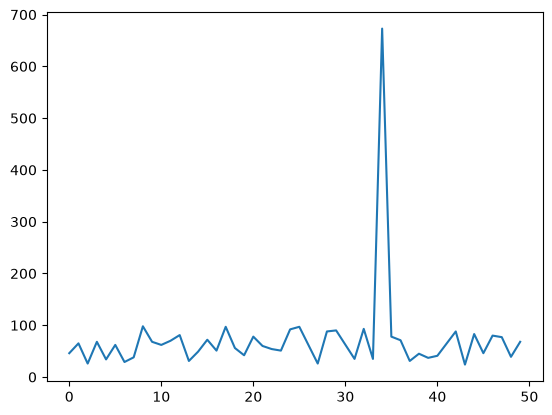

In [15]:
#We can now start to look for values that might be wrong.
#An example for FinalGrade, we see from df.describe() that the max value is 673, this is clearly wrong
#A way to visualize this is to do a plot

df["FinalGrade"].plot.line()


<Axes: >

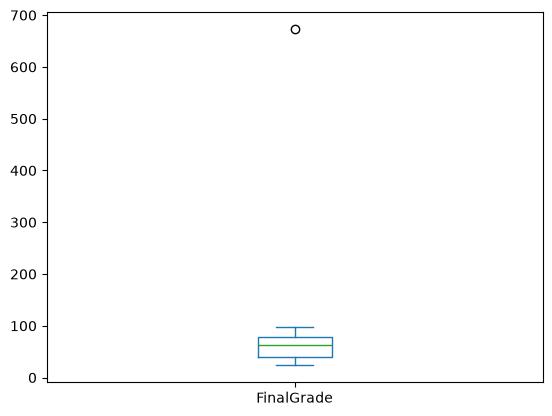

In [16]:
df["FinalGrade"].plot.box()

In [17]:
#We will look closer at removing outliers later, but we can remove them using the scipy package
#Calculate the z score
z_scores = stats.zscore(df["FinalGrade"])
abs_z_scores = np.abs(z_scores)


In [18]:
#And drop all rows in the third quantile
df.drop(df[abs_z_scores > 3].index, inplace=True)

<Axes: >

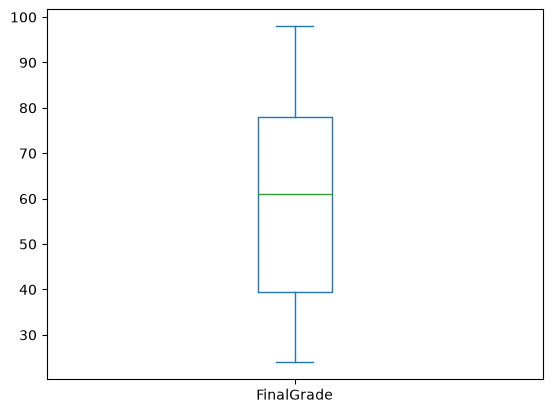

In [19]:
#Checking the column again to see if outliers are gone..
df["FinalGrade"].plot.box()

In [20]:
#Lets take a look at the end of our dataframe..
df.tail(5)


,StudentID,Age,email,hrsStudy,FinalGrade
45,62039,23,s62039@oslomet.no,4,46.0
46,42989,27,s42989@oslomet.no,0,80.0
47,85370,29,s85370@oslomet.no,2,77.0
48,63135,26,s63135@oslomet.no,9,39.0
49,28895,19,s28895@oslomet.no,10,68.0


In [21]:
#As you can see, the index counts to 49, but we have dropped several values.. to reset the index you can use
df = df.reset_index(drop=True)
df.tail(5)

,StudentID,Age,email,hrsStudy,FinalGrade
41,62039,23,s62039@oslomet.no,4,46.0
42,42989,27,s42989@oslomet.no,0,80.0
43,85370,29,s85370@oslomet.no,2,77.0
44,63135,26,s63135@oslomet.no,9,39.0
45,28895,19,s28895@oslomet.no,10,68.0


# Lets add a collumn where we translate the numeric grade to a A-F scale

In [22]:
# create a list of our conditions
conditions = [
    (df['FinalGrade'] <= 50.0),
    (df['FinalGrade'] > 50.0) & (df['FinalGrade'] <= 60.0),
    (df['FinalGrade'] > 60.0) & (df['FinalGrade'] <= 70.0),
    (df['FinalGrade'] > 70.0) & (df['FinalGrade'] <= 80.0),
    (df['FinalGrade'] > 80.0) & (df['FinalGrade'] <= 90.0),
    (df['FinalGrade'] > 90.0)
    ]

# create a list of the values we want to assign for each condition
values = ['F', 'E', 'D', 'C', 'B', 'A']

# create a new column and use np.select to assign values to it using our lists as arguments
df['Grade'] = np.select(conditions, values)

# display updated DataFrame
df.head()

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [ ]:
#We can now see how many got the different grades by using groupby
df_gradeCount = df.groupby('Grade').count()

In [ ]:
df_gradeCount.FinalGrade


Grade
A     5
B     5
C     6
D     7
E     5
F    19
Name: FinalGrade, dtype: int64

<AxesSubplot:xlabel='Grade'>

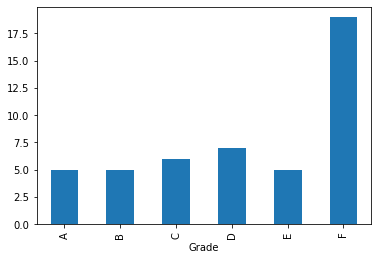

In [ ]:
#And plot a barplot of the data

df_gradeCount["FinalGrade"].plot.bar()

Lets have a quick look at some other plots as well

<AxesSubplot:xlabel='Age', ylabel='Grade'>

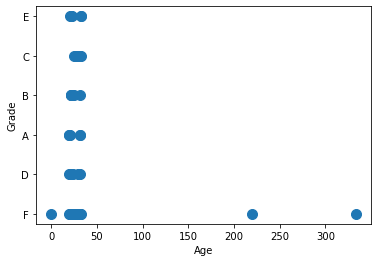

In [ ]:
df.plot.scatter(x = 'Age', y = 'Grade', s = 100)

<AxesSubplot:xlabel='Age', ylabel='Grade'>

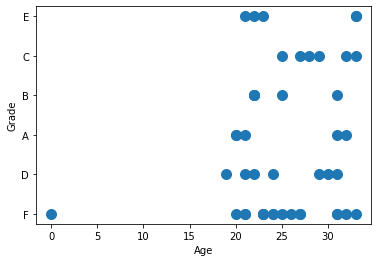

In [ ]:
#Lets just remove the two outliers for a nicer plot.
z_scores = stats.zscore(df["Age"])
abs_z_scores = np.abs(z_scores)
df.drop(df[abs_z_scores > 3].index, inplace=True)
df.plot.scatter(x = 'Age', y = 'Grade', s = 100)

<AxesSubplot:ylabel='Frequency'>

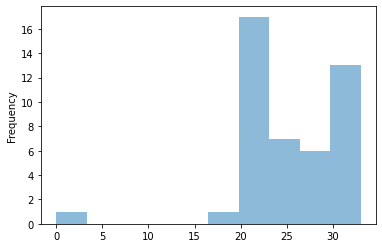

In [ ]:
df["Age"].plot.hist(alpha=0.5)

D:\Programering\Programmer\Anaconda\envs\dave3625\lib\site-packages\pandas\plotting\_matplotlib\core.py:1235: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)


<AxesSubplot:xlabel='Grade'>

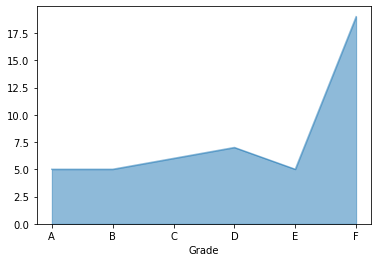

In [ ]:
df_gradeCount["FinalGrade"].plot.area(stacked=False)